# Fixed windows versus a sliding-deadline upper bound

## tl;dr

The first trace replay used origin-aligned, non-overlapping windows. Those
values are exact for that fixed policy, but they are not a universal scheduler
ceiling because a legal batch can straddle a boundary. This preregistered
follow-up recomputes the same deterministic events and measures a valid
per-event local-eligibility upper bound under equal sliding deadlines.

The implementation invariants pass and all 540 overlapping fixed-window cells
reproduce bit-for-bit. Window alignment matters in threshold-adjacent regimes:
the largest mean gap is 40.4 percentage points. At 100,000 active sessions,
`K=256`, and exact routes, a 50 ms fixed window gives 30.2% eligibility while
the local upper bound is 45.8%. At 100 ms, both are 48.0%. Sliding alignment
can recover boundary losses, but it does not remove route-frequency
fragmentation.

## Interpretation

For each event `i`, the deadline interval is `[t_i, t_i + δ]`. Its local
cohort size is the maximum number of same-route intervals sharing any point
inside that interval. An accelerated event must have local size at least `K`,
so the resulting event share is a valid upper bound. It may not be jointly
achievable: different locally feasible batches can require reusing the same
events. The exact offline packing optimum lies between fixed-window
eligibility and this local upper bound. See `paper/formalism.md`.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
PROCESSED = ROOT / "data/processed"
FIGURES = ROOT / "results/figures"
FIGURES.mkdir(parents=True, exist_ok=True)

repetitions = pd.read_csv(PROCESSED / "trace-sliding-local-bound-repetitions.csv")
summary = pd.read_csv(PROCESSED / "trace-sliding-local-bound-summary.csv")
manifest = json.loads((PROCESSED / "trace-sliding-local-bound-manifest.json").read_text())

sns.set_theme(style="whitegrid", context="notebook")
manifest["hypotheses"]

{'B1_fixed_window_never_exceeds_local_upper': True,
 'B2_grouping_hierarchy_checked': True,
 'B3_positive_alignment_gap_exists': True,
 'B4_exact_route_upper_exceeds_fixed_at_50_or_100ms': False}

## Quality checks

In [2]:
assert len(repetitions) == 540
assert len(summary) == 180
assert (repetitions["boundary_alignment_gap"] >= -1e-12).all()
assert manifest["hypotheses"]["B1_fixed_window_never_exceeds_local_upper"]
assert manifest["hypotheses"]["B2_grouping_hierarchy_checked"]
assert manifest["hypotheses"]["B3_positive_alignment_gap_exists"]
assert not manifest["hypotheses"]["B4_exact_route_upper_exceeds_fixed_at_50_or_100ms"]

old = pd.read_csv(PROCESSED / "trace-ready-cohort-repetitions.csv").rename(
    columns={"window_ms": "deadline_ms", "eligible_share": "old_fixed_share"}
)
check = repetitions.merge(
    old,
    on=["target_active_sessions", "repetition", "deadline_ms", "grouping", "threshold_k"],
    how="left",
)
assert check["old_fixed_share"].notna().all()
assert (check["fixed_window_eligible_share"] - check["old_fixed_share"]).abs().max() == 0
{
    "reproduced_cells": len(check),
    "max_fixed_window_difference": float(
        (check["fixed_window_eligible_share"] - check["old_fixed_share"]).abs().max()
    ),
    "max_mean_alignment_gap": float(summary["boundary_alignment_gap_mean"].max()),
}

{'reproduced_cells': 540,
 'max_fixed_window_difference': 0.0,
 'max_mean_alignment_gap': 0.4035119738322308}

## Policy value versus local upper bound

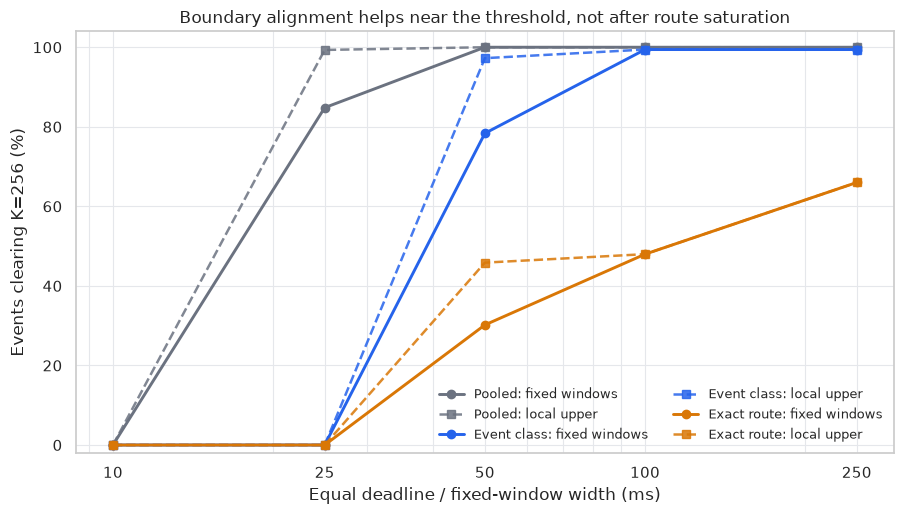

In [3]:
panel = summary[
    summary["target_active_sessions"].eq(100000)
    & summary["threshold_k"].eq(256)
].copy()
GROUP_STYLE = {
    "pooled": ("Pooled", "#6B7280"),
    "event_class": ("Event class", "#2563EB"),
    "route_key": ("Exact route", "#D97706"),
}

fig, axis = plt.subplots(figsize=(9.2, 5.3))
for grouping, (label, color) in GROUP_STYLE.items():
    series = panel[panel["grouping"].eq(grouping)].sort_values("deadline_ms")
    axis.plot(
        series["deadline_ms"],
        100 * series["fixed_window_eligible_share_mean"],
        marker="o",
        linewidth=2.1,
        color=color,
        label=f"{label}: fixed windows",
    )
    axis.plot(
        series["deadline_ms"],
        100 * series["local_upper_share_mean"],
        marker="s",
        linewidth=1.8,
        linestyle="--",
        color=color,
        alpha=0.85,
        label=f"{label}: local upper",
    )
axis.set_xscale("log")
axis.set_xticks([10, 25, 50, 100, 250])
axis.set_xticklabels(["10", "25", "50", "100", "250"])
axis.set_ylim(-2, 104)
axis.set_xlabel("Equal deadline / fixed-window width (ms)")
axis.set_ylabel("Events clearing K=256 (%)")
axis.set_title("Boundary alignment helps near the threshold, not after route saturation")
axis.legend(ncol=2, frameon=False, fontsize=9)
axis.grid(True, which="both", color="#E5E7EB", linewidth=0.8)
fig.tight_layout()
for suffix in ("png", "svg"):
    fig.savefig(
        FIGURES / f"trace-fixed-vs-sliding-upper-k256.{suffix}",
        dpi=220 if suffix == "png" else None,
        bbox_inches="tight",
        facecolor="white",
    )
plt.show()

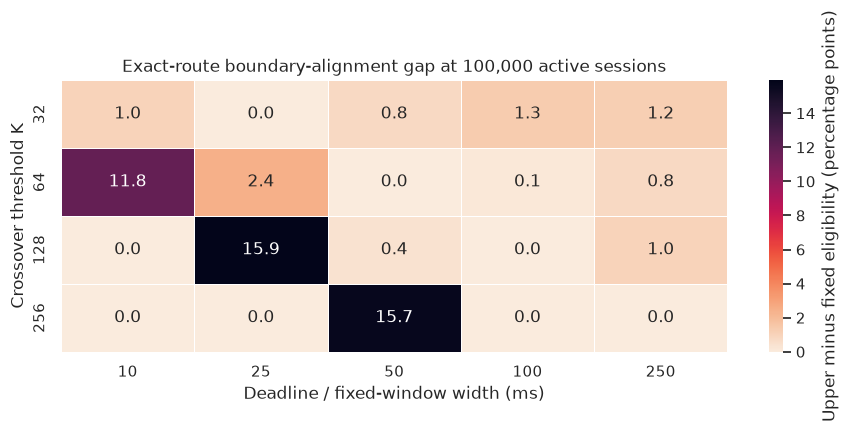

In [4]:
exact_gap = summary[
    summary["target_active_sessions"].eq(100000)
    & summary["grouping"].eq("route_key")
].pivot(index="threshold_k", columns="deadline_ms", values="boundary_alignment_gap_mean")

fig, axis = plt.subplots(figsize=(9.2, 3.8))
sns.heatmap(
    exact_gap * 100,
    annot=True,
    fmt=".1f",
    cmap="rocket_r",
    vmin=0,
    linewidths=0.7,
    linecolor="white",
    cbar_kws={"label": "Upper minus fixed eligibility (percentage points)"},
    ax=axis,
)
axis.set_xlabel("Deadline / fixed-window width (ms)")
axis.set_ylabel("Crossover threshold K")
axis.set_title("Exact-route boundary-alignment gap at 100,000 active sessions")
fig.tight_layout()
for suffix in ("png", "svg"):
    fig.savefig(
        FIGURES / f"trace-exact-route-alignment-gap.{suffix}",
        dpi=220 if suffix == "png" else None,
        bbox_inches="tight",
        facecolor="white",
    )
plt.show()

## Key cells

In [5]:
summary[
    summary["target_active_sessions"].eq(100000)
    & summary["threshold_k"].eq(256)
][
    [
        "deadline_ms",
        "grouping",
        "fixed_window_eligible_share_mean",
        "local_upper_share_mean",
        "boundary_alignment_gap_mean",
        "local_cohort_p90",
        "local_cohort_max",
    ]
].sort_values(["deadline_ms", "grouping"])

,deadline_ms,grouping,fixed_window_eligible_share_mean,local_upper_share_mean,boundary_alignment_gap_mean,local_cohort_p90,local_cohort_max
123,10,event_class,0.000000,0.000000,0.000000,72.000000,93
127,10,pooled,0.000000,0.000000,0.000000,133.000000,159
131,10,route_key,0.000000,0.000000,0.000000,66.000000,87
135,25,event_class,0.000000,0.000000,0.000000,163.333333,191
139,25,pooled,0.848119,0.993267,0.145148,309.333333,343
143,25,route_key,0.000000,0.000000,0.000000,151.666667,181
147,50,event_class,0.783606,0.972541,0.188935,312.000000,352
151,50,pooled,1.000000,1.000000,0.000000,596.333333,642
155,50,route_key,0.301902,0.458487,0.156585,291.000000,337
159,100,event_class,0.994218,0.994218,0.000000,602.666667,647


## Takeaways

1. **The scope correction matters quantitatively.** In threshold-adjacent
   cells, fixed alignment can understate local eligibility by 15–40 points.
2. **It does not rescue sparse exact routes.** At `K=256`, exact routes remain
   at zero through 25 ms even under the upper bound.
3. **The preregistered B4 hypothesis partially fails.** Exact-route `K=256`
   gains 15.7 points at 50 ms, but gains nothing at 100 ms; the script's frozen
   test required strict improvement at both selected deadlines.
4. **The upper bound is deliberately optimistic.** It ignores conflicts among
   overlapping batch opportunities, finite GPU service time, and online
   knowledge. The next quantity is the exact offline interval-packing optimum.
5. **The paper story improves:** hardware crossover, fixed policy, offline
   optimum, and local upper bound form a falsifiable boundary stack rather than
   one overstated “ceiling.”